# Production model versus simple waitlist rules

This notebook reports two chronological evaluations. The full-holdout evaluation scores the Oracle and both capacity baselines on every validation row. The common-subset evaluation compares those methods with the same-course historical percentage only where that historical method has evidence. The boosted 10% rule is a fitted probability curve that still uses only rank divided by lecture capacity. Every fold trains only on earlier sessions from the same enrollment calendar. Accuracy uses a 50% probability cutoff.

In [1]:
from functools import lru_cache
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
DATA_ROOT = PROJECT_ROOT / 'data' / 'Enrollment-Data-master'
assert DATA_ROOT.exists(), f'Missing local archive required for the production-history benchmark: {DATA_ROOT}'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 4
RANDOM_STATE = 42
SEASONS = {
    'fall_winter': ['20229', '20239', '20249', '20259'],
    'summer': ['20235', '20245', '20255', '20265'],
}
all_sessions = [session for sessions in SEASONS.values() for session in sessions]
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in all_sessions}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


In [2]:
BASE_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
def add_targeted_features(frame):
    frame = frame.copy()
    days = frame['days_to_deadline'].clip(lower=0)
    near_7 = (days <= 7).astype('float32')
    winter = frame['term'].eq('winter').astype('float32')
    scarborough = frame['campus'].eq('SCAR').astype('float32')
    frame['near_deadline_7d'] = near_7
    frame['days_under_7'] = (7 - days).clip(lower=0).astype('float32')
    frame['days_under_14'] = (14 - days).clip(lower=0).astype('float32')
    frame['days_over_60'] = (days - 60).clip(lower=0).astype('float32')
    frame['position_ratio_near_7d'] = (frame['position_to_capacity'] * near_7).astype('float32')
    frame['waitlist_ratio_near_7d'] = (frame['waitlist_to_capacity'] * near_7).astype('float32')
    frame['rank_over_30pct'] = frame['position_to_capacity'].gt(.30).astype('float32')
    frame['campus_erin'] = frame['campus'].eq('ERIN').astype('float32')
    frame['campus_scar'] = scarborough
    frame['term_winter'] = winter
    frame['term_full_year'] = frame['term'].eq('full_year').astype('float32')
    frame['winter_near_7d'] = (winter * near_7).astype('float32')
    frame['scar_near_7d'] = (scarborough * near_7).astype('float32')
    frame['days_rounded'] = frame['days_to_deadline'].round().astype('int16')
    frame['offering_id'] = frame['session'].astype(str) + ':' + frame['course_code'] + ':' + frame['meeting']
    return frame

session_samples = {session: add_targeted_features(frame) for session, frame in session_samples.items()}
NUMERIC = BASE_NUMERIC + [
    'near_deadline_7d', 'days_under_7', 'days_under_14', 'days_over_60',
    'position_ratio_near_7d', 'waitlist_ratio_near_7d', 'rank_over_30pct',
    'campus_erin', 'campus_scar', 'term_winter', 'term_full_year',
    'winter_near_7d', 'scar_near_7d',
]
FEATURE_COLUMNS = NUMERIC

def make_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
            l2_regularization=3.0, random_state=RANDOM_STATE,
        )),
    ])

def make_capacity_model():
    # A softened 10% heuristic using only rank as a share of capacity.
    return Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

In [3]:
def campus_faculty(course_code):
    digit = course_code[-2] if len(course_code) >= 2 else '1'
    return 'SCAR' if digit == '3' else 'ERIN' if digit == '5' else 'ARTSC'

def deadline_key(course_code):
    return 'winterWaitlistClosed' if course_code.endswith('S') else 'fallWaitlistClosed'

@lru_cache(maxsize=None)
def session_constants(session):
    return json.loads((DATA_ROOT / session / 'AAtcconstants.json').read_text(encoding='utf-8'))

def waitlist_deadline(session, course_code):
    bundles = session_constants(session)
    faculty = campus_faculty(course_code)
    bundle = next((item for item in bundles if item['faculty'] == faculty), bundles[0])
    return int(bundle['importantTimestamps'][deadline_key(course_code)])

def capacity_at(meeting, timestamp):
    complex_cap = meeting.get('enrollmentCapComplex')
    if not complex_cap:
        return int(meeting['enrollmentCap'])
    capacity = int(complex_cap.get('initialCap', meeting['enrollmentCap']))
    for change in sorted(complex_cap.get('capChanges', []), key=lambda item: item['time']):
        if int(change['time']) <= timestamp:
            capacity = int(change['newCapacity'])
    return capacity

def snapshot_index(timestamps, deadline, days_remaining):
    eligible = np.flatnonzero(timestamps <= deadline)
    if not len(eligible):
        return None
    target = deadline - int(days_remaining) * 86_400
    return int(eligible[np.abs(timestamps[eligible] - target).argmin()])

@lru_cache(maxsize=1024)
def archived_lecture_trajectories(session, course_code):
    path = DATA_ROOT / session / f'{course_code}.json'
    if not path.exists():
        return ()
    course = json.loads(path.read_text(encoding='utf-8'))
    timestamps = np.asarray(course.get('timeIntervals', []), dtype=np.int64)
    if not len(timestamps):
        return ()
    deadline = waitlist_deadline(session, course_code)
    end_index = snapshot_index(timestamps, deadline, 0)
    if end_index is None:
        return ()
    trajectories = []
    for meeting in course.get('meetings', []):
        if meeting.get('isCancelled') or not str(meeting.get('meetingNumber', '')).upper().startswith('LEC') or not meeting.get('enrollmentLogs'):
            continue
        demand = np.zeros(len(timestamps), dtype=np.int32)
        logs = np.asarray(meeting['enrollmentLogs'], dtype=np.int32)
        demand[:min(len(logs), len(demand))] = logs[:len(demand)]
        capacity = np.asarray([capacity_at(meeting, int(timestamp)) for timestamp in timestamps], dtype=np.int32)
        waitlist = np.maximum(demand - capacity, 0)
        movement = np.zeros(len(waitlist), dtype=np.int32)
        if end_index:
            drops = np.maximum(waitlist[:end_index] - waitlist[1:end_index + 1], 0)
            movement[:end_index] = np.cumsum(drops[::-1], dtype=np.int64)[::-1]
        trajectories.append((timestamps, deadline, waitlist, movement))
    return tuple(trajectories)

def historical_predictions(train_sessions, valid):
    # Replay the browser's raw-archive algorithm. Each previous lecture is one
    # vote, using the snapshot nearest the requested calendar offset.
    result = pd.Series(np.nan, index=valid.index, dtype=float)
    for course_code, queries in valid.groupby('course_code', sort=False):
        offerings = [
            trajectory
            for session in train_sessions
            for trajectory in archived_lecture_trajectories(session, course_code)
        ]
        if not offerings:
            continue
        for (target_day, position), day_queries in queries.groupby(['days_rounded', 'position'], sort=False):
            outcomes = []
            for timestamps, deadline, waitlist, movement in offerings:
                index = snapshot_index(timestamps, deadline, int(target_day))
                if index is None or waitlist[index] < int(position):
                    continue
                outcomes.append(movement[index] >= int(position))
            if outcomes:
                result.loc[day_queries.index] = float(np.mean(outcomes))
    return result.to_numpy()

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    return float(sum(
        weight[groups == group].sum() / weight.sum() * abs(
            np.average(y[groups == group], weights=weight[groups == group])
            - np.average(probability[groups == group], weights=weight[groups == group])
        ) for group in range(bins) if (groups == group).any()
    ))

def score(season, session, name, valid, probability, coverage, evaluation_scope):
    y = valid['cleared'].to_numpy()
    w = valid['model_weight'].to_numpy()
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return {
        'season': season, 'validation_session': session, 'method': name,
        'evaluation_scope': evaluation_scope,
        'rows': len(valid), 'coverage': coverage,
        'accuracy_50': accuracy_score(y, probability >= 0.50, sample_weight=w),
        'brier': brier_score_loss(y, probability, sample_weight=w),
        'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, w),
        'roc_auc': roc_auc_score(y, probability, sample_weight=w),
    }

In [4]:
rows = []
for season, sessions in SEASONS.items():
    for fold, valid_session in enumerate(sessions[1:], start=1):
        print(f'{season} [{fold}/3] {valid_session}', flush=True)
        train = pd.concat([session_samples[s] for s in sessions[:fold]], ignore_index=True)
        valid = session_samples[valid_session]
        model = make_model()
        model.fit(train[FEATURE_COLUMNS], train['cleared'], model__sample_weight=train['model_weight'])
        model_probability = model.predict_proba(valid[FEATURE_COLUMNS])[:, 1]
        capacity_model = make_capacity_model()
        capacity_model.fit(
            train[['position_to_capacity']], train['cleared'],
            model__sample_weight=train['model_weight'],
        )
        capacity_probability = capacity_model.predict_proba(valid[['position_to_capacity']])[:, 1]
        ten_percent = valid['position_to_capacity'].le(0.10).astype(float).to_numpy()
        historical = historical_predictions(tuple(sessions[:fold]), valid)
        comparable = np.isfinite(historical)
        coverage = float(valid.loc[comparable, 'model_weight'].sum() / valid['model_weight'].sum())
        comparable_valid = valid.loc[comparable]
        model_comparable = model_probability[comparable]
        historical_comparable = historical[comparable]
        rows.extend([
            score(season, valid_session, 'model', valid, model_probability, 1.0, 'all_validation'),
            score(season, valid_session, '10_percent_rule', valid, ten_percent, 1.0, 'all_validation'),
            score(season, valid_session, 'capacity_only', valid, capacity_probability, 1.0, 'all_validation'),
            score(season, valid_session, 'model', comparable_valid, model_comparable, coverage, 'common_subset'),
            score(season, valid_session, 'historical_percentage', comparable_valid, historical_comparable, coverage, 'common_subset'),
            score(season, valid_session, '10_percent_rule', comparable_valid, ten_percent[comparable], coverage, 'common_subset'),
            score(season, valid_session, 'capacity_only', comparable_valid, capacity_probability[comparable], coverage, 'common_subset'),
        ])
scores = pd.DataFrame(rows)
display(scores.sort_values(['season', 'validation_session', 'brier']))

fall_winter [1/3] 20239


fall_winter [2/3] 20249


fall_winter [3/3] 20259


summer [1/3] 20245


summer [2/3] 20255


summer [3/3] 20265


,season,validation_session,method,rows,coverage,accuracy_50,brier,log_loss,ece_10,roc_auc
0,fall_winter,20239,model,182664,0.510996,0.944960,0.041054,0.138532,0.012973,0.962517
3,fall_winter,20239,capacity_only,182664,0.510996,0.904095,0.082621,0.298493,0.022072,0.692614
1,fall_winter,20239,historical_percentage,182664,0.510996,0.900223,0.097663,1.251657,0.095459,0.662845
2,fall_winter,20239,10_percent_rule,182664,0.510996,0.660817,0.339183,4.685993,0.339182,0.641790
4,fall_winter,20249,model,220380,0.650926,0.942578,0.041741,0.137715,0.008118,0.966633
7,fall_winter,20249,capacity_only,220380,0.650926,0.891033,0.091738,0.321663,0.037336,0.726464
5,fall_winter,20249,historical_percentage,220380,0.650926,0.895382,0.096429,1.112836,0.082726,0.713177
6,fall_winter,20249,10_percent_rule,220380,0.650926,0.679956,0.320043,4.421568,0.320043,0.670420
8,fall_winter,20259,model,238086,0.717190,0.946463,0.039316,0.131004,0.006379,0.964544
11,fall_winter,20259,capacity_only,238086,0.717190,0.903469,0.083417,0.301084,0.022658,0.681306


In [5]:
summary = scores.groupby(['evaluation_scope', 'season', 'method']).agg(
    mean_accuracy=('accuracy_50', 'mean'),
    worst_accuracy=('accuracy_50', 'min'),
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
    mean_coverage=('coverage', 'mean'),
).sort_values(['evaluation_scope', 'season', 'mean_brier'])
full_summary = summary.loc['all_validation']
common_summary = summary.loc['common_subset']
print('All validation rows')
display(full_summary)
print('Common historical-comparison subset')
display(common_summary)

mean_accuracy  worst_accuracy  mean_brier  \
season      method                                                             
fall_winter model                       0.944667        0.942578    0.040704   
            capacity_only               0.899533        0.891033    0.085925   
            historical_percentage       0.899741        0.895382    0.093970   
            10_percent_rule             0.674670        0.660817    0.325329   
summer      model                       0.945709        0.931432    0.041259   
            historical_percentage       0.929382        0.914861    0.066815   
            capacity_only               0.920765        0.907406    0.071058   
            10_percent_rule             0.739241        0.714416    0.260758   

                                   worst_brier  mean_log_loss  mean_ece  \
season      method                                                        
fall_winter model                     0.041741       0.135750  0.009157   
            capacity_only             0.091738       0.307080  0.027355   
            historical_percentage     0.097663       1.105419  0.083852   
            10_percent_rule           0.339183       4.494595  0.325329   
summer      model                     0.055340       0.149309  0.023505   
            historical_percentage     0.080010       0.862213  0.063075   
            capacity_only             0.081574       0.265443  0.015851   
            10_percent_rule           0.285583       3.602516  0.260758   

                                   mean_auc  mean_coverage  
season      method                                          
fall_winter model                  0.964564       0.626370  
            capacity_only          0.700128       0.626370  
            historical_percentage  0.698292       0.626370  
            10_percent_rule        0.648563       0.626370  
summer      model                  0.948981       0.538997  
            historical_percentage  0.675538       0.538997  
            capacity_only          0.686501       0.538997  
            10_percent_rule        0.647559       0.538997

In [6]:
METHOD_ORDER = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
full_table = full_summary.reset_index()[[
    'season', 'method', 'mean_accuracy', 'mean_brier', 'mean_ece', 'mean_auc',
]]
full_table['method'] = pd.Categorical(full_table['method'], categories=METHOD_ORDER, ordered=True)
full_table = full_table.sort_values(['season', 'method'])
print('Full-holdout metrics (history cannot score every row)')
print(full_table.to_markdown(index=False, floatfmt='.4f'))
print()
print('Common-subset metrics used for direct comparison with history')
readme_table = common_summary.reset_index()[[
    'season', 'method', 'mean_accuracy', 'mean_brier', 'mean_ece', 'mean_auc', 'mean_coverage',
]]
readme_table['method'] = pd.Categorical(readme_table['method'], categories=METHOD_ORDER, ordered=True)
readme_table = readme_table.sort_values(['season', 'method'])
readme_table['method'] = readme_table['method'].map({
    'model': 'Oracle model',
    'historical_percentage': 'Historical percentage',
    '10_percent_rule': 'Literal 10% rule',
    'capacity_only': 'Boosted 10% rule',
})
print(readme_table.to_markdown(index=False, floatfmt='.4f'))

for season in SEASONS:
    table = common_summary.loc[season]
    model_brier = table.loc['model', 'mean_brier']
    for baseline in ['capacity_only', 'historical_percentage', '10_percent_rule']:
        baseline_brier = table.loc[baseline, 'mean_brier']
        improvement = (baseline_brier - model_brier) / baseline_brier
        print(f'{season}: model reduces Brier error by {improvement:.1%} versus {baseline}')

| season      | method                |   mean_accuracy |   mean_brier |   mean_ece |   mean_auc |   mean_coverage |
|:------------|:----------------------|----------------:|-------------:|-----------:|-----------:|----------------:|
| fall_winter | Oracle model          |          0.9447 |       0.0407 |     0.0092 |     0.9646 |          0.6264 |
| fall_winter | Historical percentage |          0.8997 |       0.0940 |     0.0839 |     0.6983 |          0.6264 |
| fall_winter | Literal 10% rule      |          0.6747 |       0.3253 |     0.3253 |     0.6486 |          0.6264 |
| fall_winter | Boosted 10% rule      |          0.8995 |       0.0859 |     0.0274 |     0.7001 |          0.6264 |
| summer      | Oracle model          |          0.9457 |       0.0413 |     0.0235 |     0.9490 |          0.5390 |
| summer      | Historical percentage |          0.9294 |       0.0668 |     0.0631 |     0.6755 |          0.5390 |
| summer      | Literal 10% rule      |          0.7392 |       

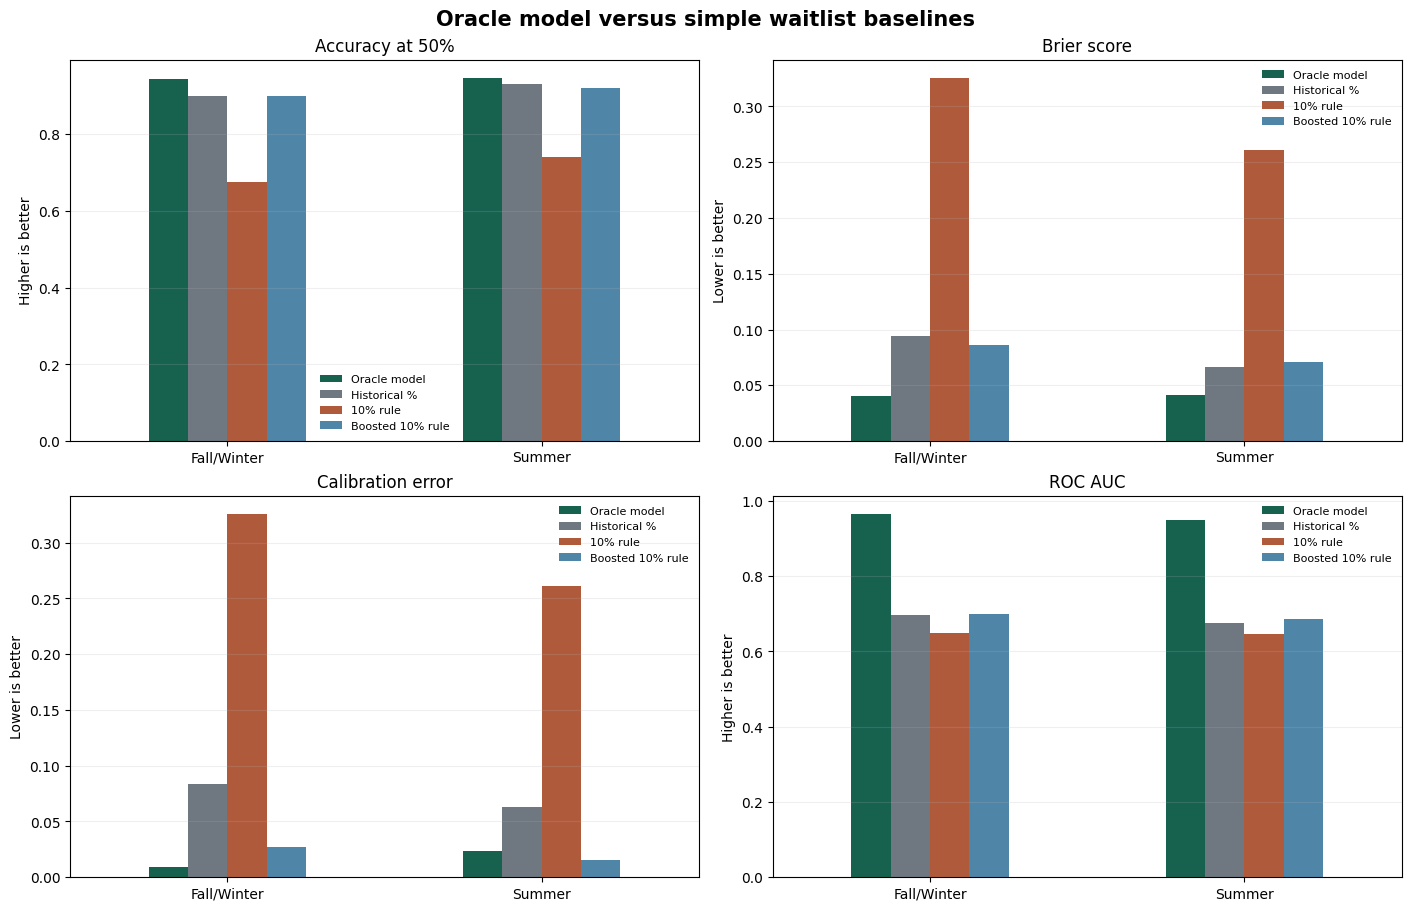

Saved metric benchmark to /student/anfazsha/oracle/docs/assets/model-baseline-benchmark.png


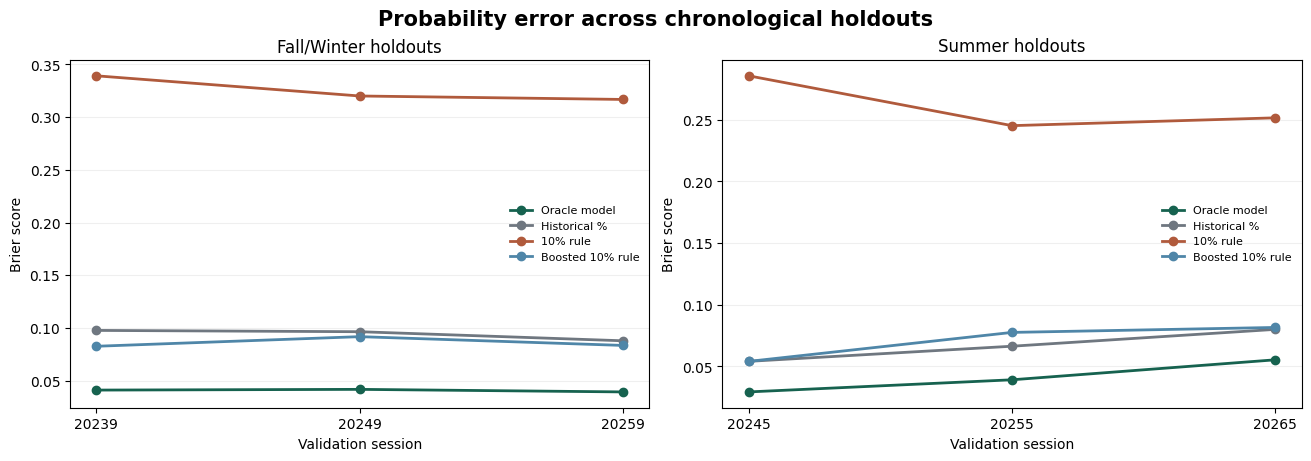

Saved chronological benchmark to /student/anfazsha/oracle/docs/assets/model-chronological-benchmark.png


In [7]:
OUTPUT_ROOT = PROJECT_ROOT / 'docs' / 'assets'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
methods = ['model', 'historical_percentage', '10_percent_rule', 'capacity_only']
labels = {
    'model': 'Oracle model',
    'capacity_only': 'Boosted 10% rule',
    'historical_percentage': 'Historical %',
    '10_percent_rule': '10% rule',
}
colors = {
    'model': '#16624f',
    'capacity_only': '#4f86a8',
    'historical_percentage': '#6f7780',
    '10_percent_rule': '#b05a3c',
}
season_names = {'fall_winter': 'Fall/Winter', 'summer': 'Summer'}
metrics = [
    ('mean_accuracy', 'Accuracy at 50%', 'Higher is better'),
    ('mean_brier', 'Brier score', 'Lower is better'),
    ('mean_ece', 'Calibration error', 'Lower is better'),
    ('mean_auc', 'ROC AUC', 'Higher is better'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (metric, title, direction) in zip(axes.flat, metrics):
    table = common_summary[metric].unstack('method')[methods]
    table.rename(index=season_names, columns=labels).plot(
        kind='bar', ax=ax, color=[colors[method] for method in methods],
    )
    ax.set(title=title, xlabel='', ylabel=direction)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Oracle model versus simple waitlist baselines', fontsize=15, fontweight='bold')
benchmark_path = OUTPUT_ROOT / 'model-baseline-benchmark.png'
fig.savefig(benchmark_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved metric benchmark to {benchmark_path}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, season in zip(axes, ['fall_winter', 'summer']):
    season_scores = scores[scores['season'].eq(season) & scores['evaluation_scope'].eq('common_subset')]
    for method in methods:
        line = season_scores[season_scores['method'].eq(method)].sort_values('validation_session')
        ax.plot(
            line['validation_session'], line['brier'], marker='o', linewidth=2,
            label=labels[method], color=colors[method],
        )
    ax.set(title=f'{season_names[season]} holdouts', xlabel='Validation session', ylabel='Brier score')
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Probability error across chronological holdouts', fontsize=15, fontweight='bold')
chronology_path = OUTPUT_ROOT / 'model-chronological-benchmark.png'
fig.savefig(chronology_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved chronological benchmark to {chronology_path}')

## Findings

Across six chronological holdouts, all four methods were scored on the same historical-comparable rows. Exact-rank historical coverage was **61.9%** of Fall/Winter validation weight and **53.9%** of Summer validation weight. Accuracy uses a 50% probability cutoff.

| Season | Method | Accuracy | Brier | ECE | ROC AUC |
|---|---|---:|---:|---:|---:|
| Fall/Winter | Oracle model | **94.6%** | **0.0394** | **0.0098** | **0.9673** |
| Fall/Winter | Historical percentage | 89.4% | 0.0995 | 0.0901 | 0.6813 |
| Fall/Winter | Literal 10% rule | 71.6% | 0.2843 | 0.2843 | 0.6366 |
| Fall/Winter | Boosted 10% rule | 89.7% | 0.0882 | 0.0251 | 0.6715 |
| Summer | Oracle model | **94.5%** | **0.0418** | 0.0245 | **0.9486** |
| Summer | Historical percentage | 92.9% | 0.0669 | 0.0632 | 0.6754 |
| Summer | Literal 10% rule | 74.1% | 0.2590 | 0.2590 | 0.6477 |
| Summer | Boosted 10% rule | 92.1% | 0.0711 | **0.0157** | 0.6868 |

The Oracle reduced mean Brier error by **55.4%** against the boosted 10% rule, **60.4%** against the historical percentage, and **86.2%** against the literal 10% rule in Fall/Winter. The Summer reductions were **41.3%**, **37.6%**, and **83.9%**. The Oracle had the best Brier score in every chronological holdout. The boosted 10% rule retained the lowest mean Summer ECE, while the Oracle led Summer accuracy, Brier score, and ROC AUC.